# Set up workspace

In [28]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
from srm import run_bcsd

# Run through clunky BCSD workflow

In [3]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [6]:
# Spatial information if subsetting run to a single country

df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

subset_bounds = [lat_min, lat_max, lon_min, lon_max]

In [7]:
# Rechunking in between steps
dict_all = run_bcsd.run_bcsd(
    gcm=RUN_PARAMETERS["gcm"],
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    var_name=RUN_PARAMETERS["var_name"],
    verbose=True,
    rechunk_workflow=True,
    subset_bounds=subset_bounds,
)

Loaded data: 1.13 seconds
Subset time: 0.00 seconds
Rechunked obs to full space: 4.61 seconds
Interpolated obs to coarse grid: 59.87 seconds
Detrended data: 13.41 seconds


  0%|          | 0/620 [00:00<?, ?it/s]/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
100%|██████████| 620/620 [02:06<00:00,  4.90it/s]


Quantile mapped historical: 127.77 seconds


100%|██████████| 620/620 [02:58<00:00,  3.47it/s]


Quantile mapped future: 179.58 seconds
Added back trend: 0.02 seconds
Rechunked all to full time: 2.63 seconds
Calculate error map for spatial disaggregation: 9.14 seconds
Downscaled historical: 1.35 seconds
Downscaled future: 3.85 seconds


# Save results

In [10]:
%%time
for key in ["model_hist_debiased_downscaled", "scenario_debiased_downscaled"]:
    print(key)
    s3_path = "s3://carbonplan-scratch/srm-scratch/v0.2_SouthAfrica/" + key + ".zarr"
    ds = dict_all[key].to_dataset(name=RUN_PARAMETERS["var_name"])
    ds.to_zarr(s3_path, encoding={var: {"shards": None} for var in ds.data_vars}, mode="w")

model_hist_debiased_downscaled


/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


scenario_debiased_downscaled
CPU times: user 27.1 s, sys: 1.1 s, total: 28.2 s
Wall time: 15.6 s


/opt/coiled/env/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


# Look at results

In [11]:
%%time
dict_all["model_hist_debiased_downscaled"] = dict_all["model_hist_debiased_downscaled"].chunk(
    time=1000, lat=7, lon=7
)

CPU times: user 789 ms, sys: 22.9 ms, total: 812 ms
Wall time: 811 ms


In [12]:
%%time
dict_all["scenario_debiased_downscaled"] = dict_all["scenario_debiased_downscaled"].chunk(
    time=1000, lat=7, lon=7
)

CPU times: user 1.83 s, sys: 46.9 ms, total: 1.87 s
Wall time: 1.87 s


In [13]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_1344/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_1344/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


Text(0.5, 1.0, 'Raw coarse model data')

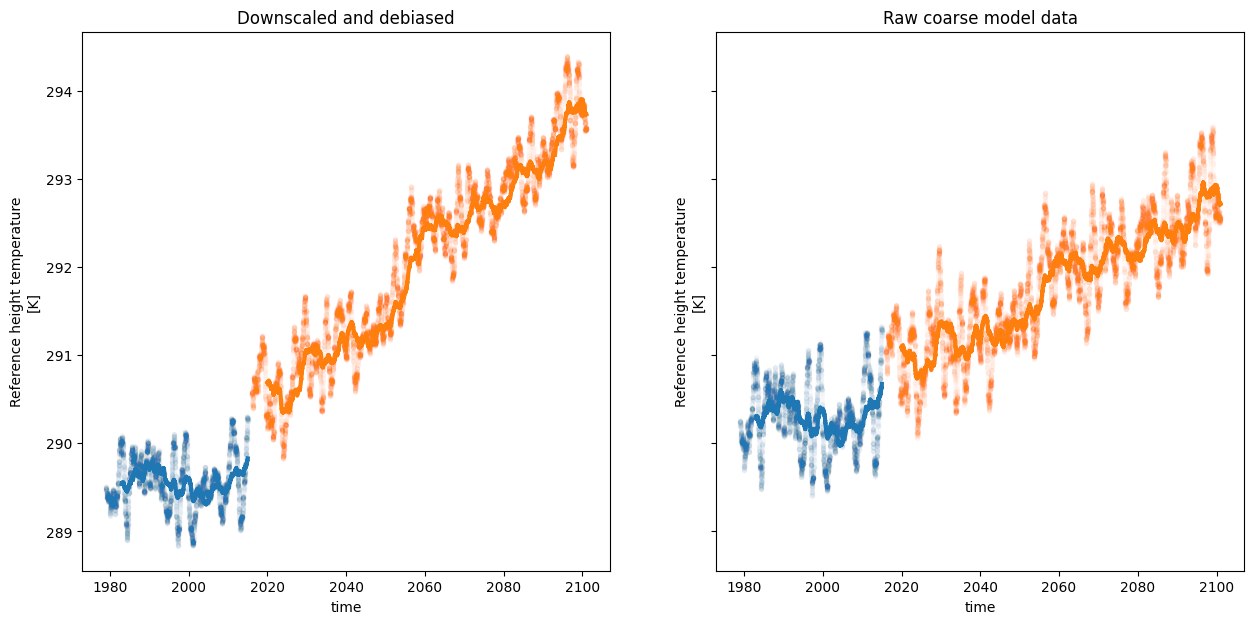

In [35]:
[fig, ax] = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(15, 7))

plt.subplot(1, 2, 1)
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C0", linewidth=3)

dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["scenario_debiased_downscaled"].sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
).rolling(time=365 * 5).mean().plot(color="C1", linewidth=3)
ax[0].set_title("Downscaled and debiased")

plt.subplot(1, 2, 2)
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C0")
dict_all["model_hist"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C0", linewidth=3)

dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365
).mean().plot(marker=".", linewidth=0, alpha=0.01, color="C1")
dict_all["model_scenario"].sel(lat=cape_town_y, lon=cape_town_x, method="nearest").rolling(
    time=365 * 5
).mean().plot(color="C1", linewidth=3)
ax[1].set_title("Raw coarse model data")